# STA365 Homework 6

### Question 1

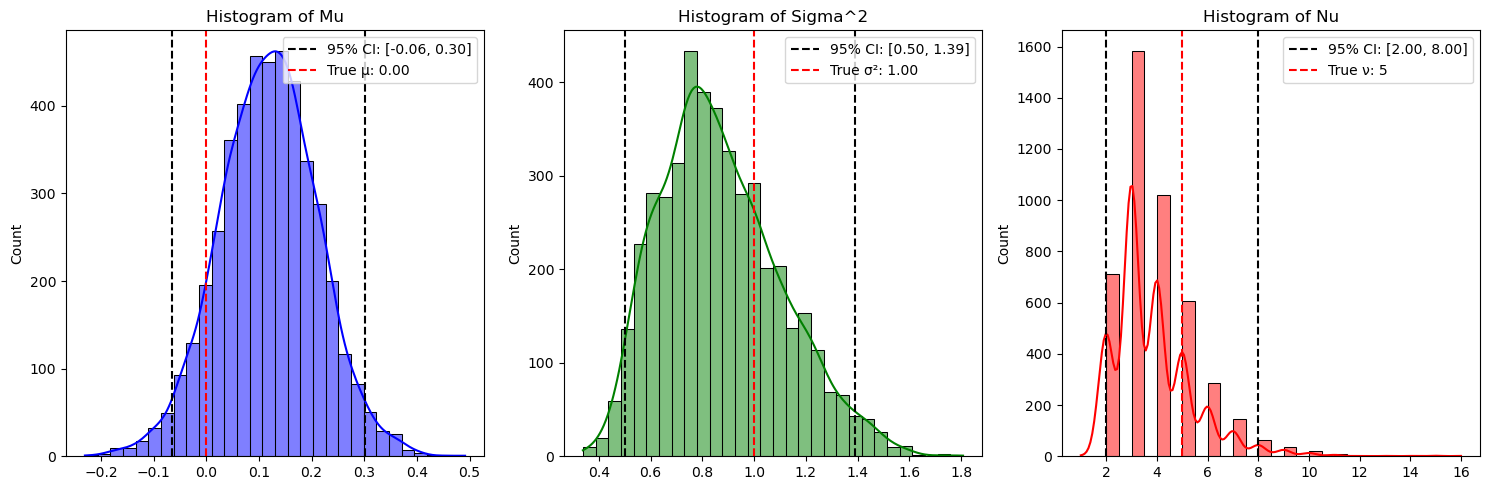

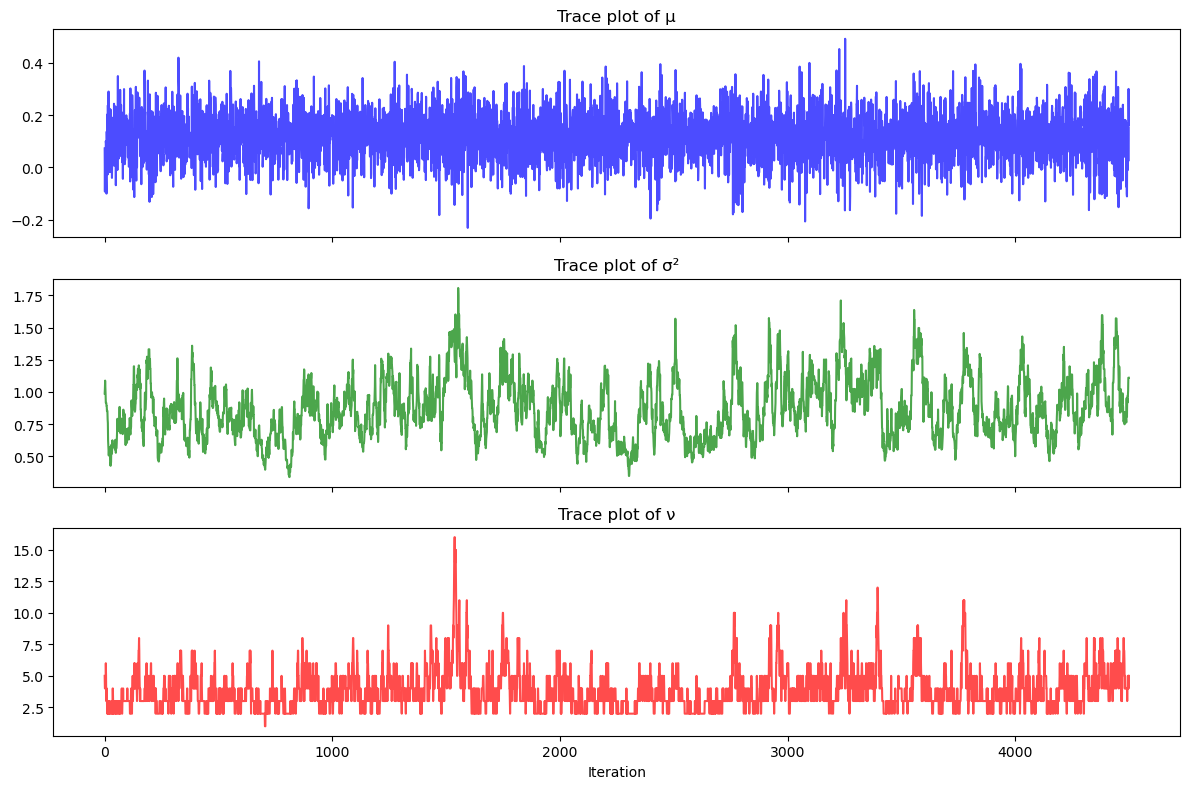

In [9]:
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(365)

# simulated data from t-distribution
x = stats.t.rvs(df=5, loc=0, scale=1, size=100)

# log posterior function for ν
def log_posterior_nu(nu, x, mu, sigma2):
    if not (1 <= nu <= 100):
        return -np.inf  # Enforce discrete uniform prior
    log_likelihood = np.sum(stats.t.logpdf(x, df=nu, loc=mu, scale=np.sqrt(sigma2)))
    log_prior = -np.log(100)  # log(1/100) for discrete uniform
    return log_likelihood + log_prior

# Metropolis-within-Gibbs sampler
def metropolis_within_gibbs(x, mu_0, tau_0, sigma_0, n_iter=1000, burn_in=500):
    n = len(x)
    
    # initialize parameters based on the simulated data (x)
    mu = np.mean(x)
    sigma2 = np.var(x)
    nu = np.random.randint(1, 101)

    samples = np.zeros((n_iter, 3))  # store (mu, sigma2, nu)

    for iter in range(n_iter):
        # sample mu | sigma2, nu, x
        mu_var = 1 / (tau_0 + n / sigma2)
        mu_mean = mu_var * (tau_0 * mu_0 + np.sum(x) / sigma2)
        mu = np.random.normal(mu_mean, np.sqrt(mu_var))

        # sample sigma2 | mu, nu, x using Metropolis-Hastings with log scale
        sigma2_proposed = np.exp(np.log(sigma2) + np.random.normal(0, 0.1))  # Log-space proposal
        log_p_proposed = np.sum(stats.t.logpdf(x, df=nu, loc=mu, scale=np.sqrt(sigma2_proposed))) \
                         + stats.halfnorm.logpdf(np.sqrt(sigma2_proposed), scale=sigma_0)
        log_p_current = np.sum(stats.t.logpdf(x, df=nu, loc=mu, scale=np.sqrt(sigma2))) \
                        + stats.halfnorm.logpdf(np.sqrt(sigma2), scale=sigma_0)
        log_alpha = log_p_proposed - log_p_current
        
        if np.log(np.random.uniform()) < log_alpha:
            sigma2 = sigma2_proposed

        # sample ν | mu, sigma2, x using MH
        nu_proposed = np.clip(nu + np.random.choice([-2, -1, 1, 2]), 1, 100)
        log_alpha = log_posterior_nu(nu_proposed, x, mu, sigma2) - log_posterior_nu(nu, x, mu, sigma2)
        
        if np.log(np.random.uniform()) < log_alpha:
            nu = nu_proposed

        # store samples
        samples[iter] = [mu, sigma2, nu]

    # discard burn-in samples
    return samples[burn_in:]


# run Metropolis-within-Gibbs sampler
mu_0, tau_0, sigma_0 = 0, 1, 1  # example hyperparameters
# run sampler with burn-in removal
samples = metropolis_within_gibbs(x, mu_0, tau_0, sigma_0, n_iter=5000, burn_in=500)

# extract samples after burn-in
mu_samples = samples[:, 0]
sigma2_samples = samples[:, 1]
nu_samples = samples[:, 2]




# 95% CI for each parameter
mu_ci = np.percentile(mu_samples, [2.5, 97.5])
sigma2_ci = np.percentile(sigma2_samples, [2.5, 97.5])
nu_ci = np.percentile(nu_samples, [2.5, 97.5])

# true parameter values used to generate the data (x)
true_mu = 0
true_sigma2 = 1
true_nu = 5

# plot histograms for each parameter
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Mu histogram
sns.histplot(mu_samples, kde=True, ax=axes[0], color='blue', bins=30)
axes[0].axvline(mu_ci[0], color='black', linestyle='--', label=f'95% CI: [{mu_ci[0]:.2f}, {mu_ci[1]:.2f}]')
axes[0].axvline(mu_ci[1], color='black', linestyle='--')
axes[0].axvline(true_mu, color='red', linestyle='--', label=f'True μ: {true_mu:.2f}')
axes[0].set_title('Histogram of Mu')
axes[0].legend()

# Sigma^2 histogram
sns.histplot(sigma2_samples, kde=True, ax=axes[1], color='green', bins=30)
axes[1].axvline(sigma2_ci[0], color='black', linestyle='--', label=f'95% CI: [{sigma2_ci[0]:.2f}, {sigma2_ci[1]:.2f}]')
axes[1].axvline(sigma2_ci[1], color='black', linestyle='--')
axes[1].axvline(true_sigma2, color='red', linestyle='--', label=f'True σ²: {true_sigma2:.2f}')
axes[1].set_title('Histogram of Sigma^2')
axes[1].legend()

# Nu histogram
sns.histplot(nu_samples, kde=True, ax=axes[2], color='red', bins=30)
axes[2].axvline(nu_ci[0], color='black', linestyle='--', label=f'95% CI: [{nu_ci[0]:.2f}, {nu_ci[1]:.2f}]')
axes[2].axvline(nu_ci[1], color='black', linestyle='--')
axes[2].axvline(true_nu, color='red', linestyle='--', label=f'True ν: {true_nu}')
axes[2].set_title('Histogram of Nu')
axes[2].legend()

plt.tight_layout()
plt.show()


# trace plots
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(mu_samples, color='blue', alpha=0.7)
axes[0].set_title("Trace plot of μ")

axes[1].plot(sigma2_samples, color='green', alpha=0.7)
axes[1].set_title("Trace plot of σ²")

axes[2].plot(nu_samples, color='red', alpha=0.7)
axes[2].set_title("Trace plot of ν")

plt.xlabel("Iteration")
plt.tight_layout()
plt.show()

#### Inference

From the histograms above, we see that:
* The 95% credible intervals for $\mu$, $\sigma^2$, and $\nu$ contain their true values (true values defined in the code as: $\mu=0$, $\sigma^2=1$, and $\nu=5$)

From the trace plots above, we see that:
* After discarding the burn-in period (first 500 iterations), the trace plot of $\mu$ mostly resembles a random walk around 0, as desired.
* After discarding the burn-in period (first 500 iterations), the trace plot of $\sigma^2$ mostly resembles a random walk centered around 1, as desired.
* After discarding the burn-in period (first 500 iterations), the trace plot of $\nu$ shows a random walk exploring the discrete values around the true value of 5, and is centered around 5, as desired.

Therefore, the trace plots show that the chains are mixing and converging well.

### Question 2

Sequential sampling (4 chains in 1 job)
CompoundStep
>Metropolis: [nu]
>NUTS: [mu, sigma]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 11 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



===== Posterior Summary for n=20 =====


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,0.09991,0.32838,-0.50776,0.72382,0.00400,0.00394,7023.05750,5746.02800,1.00393
sigma,1.38915,0.33732,0.73307,2.03659,0.06792,0.04860,23.43145,63.10126,1.11161
nu,45.90642,29.81068,1.00000,89.00000,11.67253,8.65380,7.91825,37.47550,1.46615


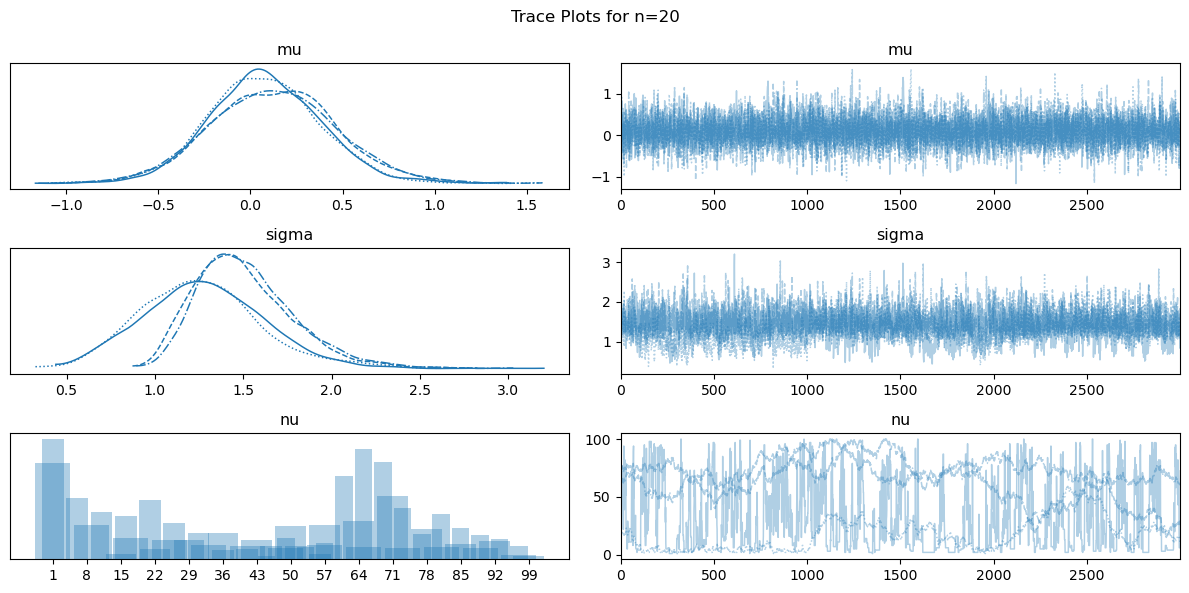

Sequential sampling (4 chains in 1 job)
CompoundStep
>Metropolis: [nu]
>NUTS: [mu, sigma]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 11 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



===== Posterior Summary for n=100 =====


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,0.04888,0.12380,-0.19000,0.28114,0.01146,0.00854,124.48668,212.04354,1.02550
sigma,1.06784,0.22267,0.73562,1.48440,0.08896,0.06749,7.80668,31.24388,1.44873
nu,20.69717,27.24235,2.00000,75.00000,12.88054,9.77814,6.80349,72.08127,1.59684


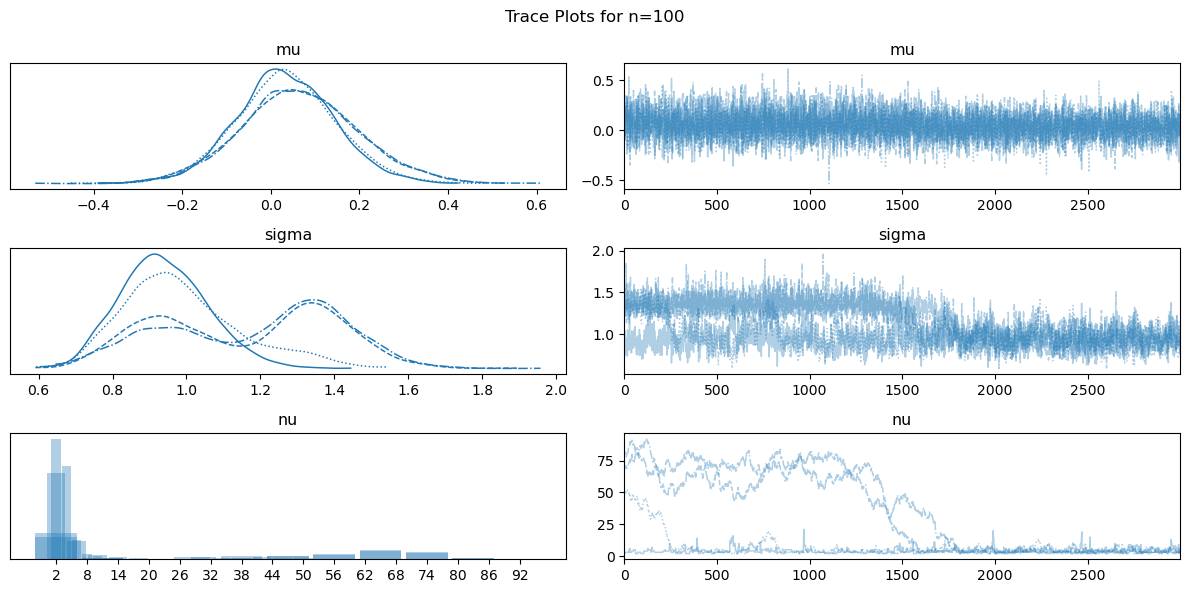

Sequential sampling (4 chains in 1 job)
CompoundStep
>Metropolis: [nu]
>NUTS: [mu, sigma]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 11 seconds.



===== Posterior Summary for n=500 =====


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,0.01767,0.04776,-0.07213,0.10601,0.00048,0.00044,9994.44658,6993.09240,1.00011
sigma,0.90590,0.04864,0.81438,0.99673,0.00106,0.00075,2125.46820,3902.74135,1.00245
nu,4.31292,0.82060,3.00000,6.00000,0.02446,0.01756,1167.48882,1561.56015,1.00336


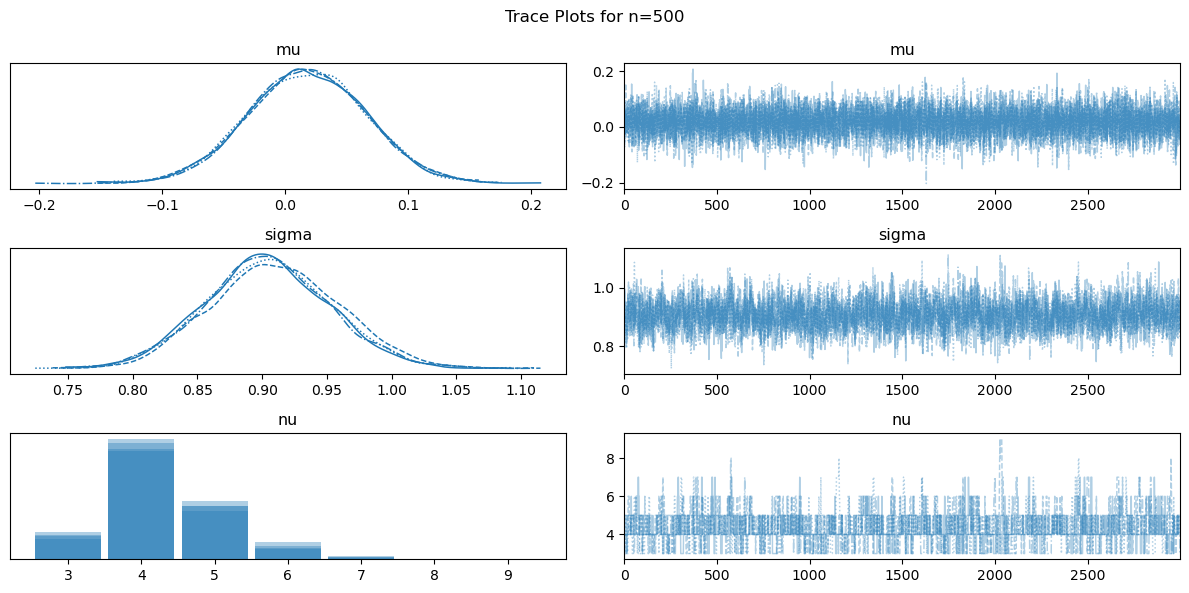

Sequential sampling (4 chains in 1 job)
CompoundStep
>Metropolis: [nu]
>NUTS: [mu, sigma]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 12 seconds.



===== Posterior Summary for n=1000 =====


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,-0.00640,0.03550,-0.07073,0.06188,0.00034,0.00033,11157.96118,8082.48740,1.00023
sigma,0.94335,0.03409,0.88197,1.00982,0.00066,0.00047,2740.93314,4331.20551,1.00078
nu,4.29308,0.52206,4.00000,5.00000,0.01433,0.01014,1343.44963,1371.28766,1.00437


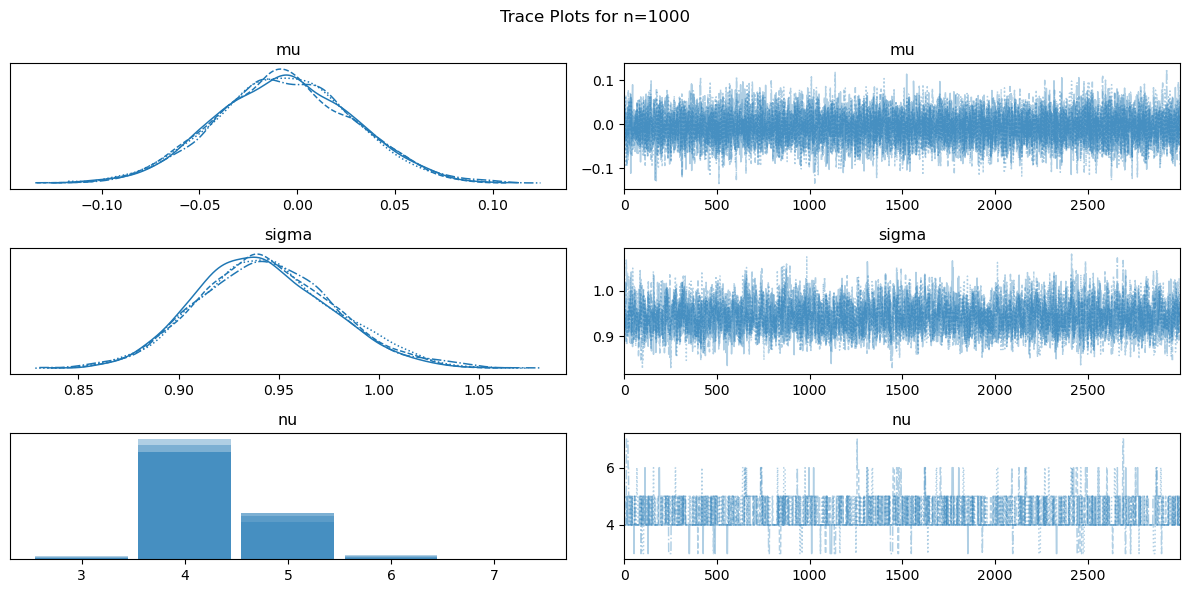

In [3]:
import numpy as np
import pymc as pymc
import arviz as az
import matplotlib.pyplot as plt
from IPython.display import display

# set random seed for data generation (separate from MCMC seed)
np.random.seed(365)

# true parameters
true_mu = 0
true_sigma = 1
true_nu = 5

# exploring multiple sample sizes

sample_sizes = [20, 100, 500, 1000]
all_traces = {}

for n in sample_sizes:
    np.random.seed(365)
    x = np.random.standard_t(df=true_nu, size=n) * true_sigma + true_mu
    
    with pymc.Model() as model_multi_n:
        mu = pymc.Normal("mu", mu=0.0, sigma=10.0)
        sigma = pymc.HalfNormal("sigma", sigma=5.0)
        nu = pymc.DiscreteUniform("nu", lower=1, upper=100)
        
        y_obs = pymc.StudentT("y_obs", nu=nu, mu=mu, sigma=sigma, observed=x)
        
        step_for_nu = pymc.Metropolis(vars=[nu])
        
        trace_multi_n = pymc.sample(
            3000,
            tune=1000,
            chains=4,
            cores=1,
            step=[step_for_nu],
            random_seed=365
        )
        
    all_traces[n] = trace_multi_n
    
    print(f"\n===== Posterior Summary for n={n} =====")
    summary_df = az.summary(trace_multi_n, var_names=["mu", "sigma", "nu"], round_to=5)
    display(summary_df)  # display summary table for each n
    
    # trace plots
    az.plot_trace(trace_multi_n, var_names=["mu", "sigma", "nu"])
    plt.suptitle(f"Trace Plots for n={n}")
    plt.tight_layout()
    plt.show()

#### Summary of Findings

From the summary tables and plots above, we see that when using sample size **n=20**:
* The r_hat statistic for $\mu$ is less than 1.01 but the r_hat statistic for $\sigma$ and $\nu$ is 1.11 and 1.47, respectively, which indicates that these chains have not converged on the same result (which can be seen in the trace plots).
* In this example, we took 4 chains of 3,000 samples, so we took 12,000 samples in total. Looking at ess_bulk, we see that for $\mu$ we took the rough equivalent of 7,023 independent samples of $\mu$, but only 23 independent samples for $\sigma$ and 8 independent samples for $\nu$. This is very little considering we took a total of 12,000 samples across the 4 chains, and would help explain the large r_hat values for $\sigma$ and $\nu$.
* The 94% HDIs contain the true parameter values in all three cases, although the HDI for $\nu$ is very wide since we did not obtain a lot of good information about this parameter.
* The mean of $\nu$ is approximately 45.9, which is very different than its true value of 5.
* The trace plots of $\nu$ show a lot of variability between the paths of the 4 chains, and show the chains did not mix well or converge on the same value.
* **These points suggest that using a sample size of n=20 is too small to obtain reliable estimates of the posterior distribution.**

From the summary tables and plots above, we see that when using sample size **n=100**:
* The r_hat statistic for all three parameters is greater than 1.01, indicating the chains still don't agree sufficiently well.
* ess_bulk is approximately 124 for $\mu$, 8 for $\sigma$, and 7 for $\nu$. This indicates we still don't have a lot of precise information on these parameters even with n=100 samples. 
* The 94% HDIs still contain the true parameter values in all three cases, but the HDI for $\nu$ is still very wide.
* The estimated mean of $\nu$ (20.7) is now a little closer to the true value of 5 compared to before, but this estimate is still not very good.
* The trace plots of $\sigma$ and $\nu$ show significant differences in the chains for these parameters, indicating they did not mix well or converge on the same value.
* **These points suggest that using a sample size of n=100 is also too small to obtain reliable estimates of the posterior distribution.**

From the summary tables and plots above, we see that when using sample size **n=500**:
* The r_hat statistic for all three parameters is now less than 1.01, indicating the chains are mixing well and are agreeing.
* ess_bulk is approximately 9,994 for $\mu$, 2,125 for $\sigma$, and 1,167 for $\nu$. These values are much higher than in the previous two cases. Compared to 12,000, the total number of samples taken, having only 2,125 for $\sigma$ and 1,167 for $\nu$ is still smaller than we'd like, but these larger values allow us to be more confident in the estimates than before.
* The 94% HDIs of $\mu$ and $\nu$ contain their true value. Notice that the HDI for $\nu$ is much narrower than in the previous two cases, giving us a more precise estimate. This time, the true value of $\sigma$ is not captured in the 94% HDI, but is located just outside the interval of (0.81438,0.99673). This could be due to random variation, or because of our model.
* Looking at the trace plots of each parameter, we see that the chains seem to agree this time.
* **Although, when using sample size n=500, the results for $\nu$ look more reliable, obtaining a HDI for $\sigma$ not including its true value suggests that using a larger sample size may provide better results overall.**

From the summary tables and plots above, we see that when using sample size **n=1000**:
* The r_hat statistic for all three parameters is now less than 1.01, indicating the chains are mixing well and are agreeing.
* ess_bulk is 11,158 for $\mu$, 2,741 for $\sigma$, and 1,343 for $\nu$. These values are higher than in each of the previous cases, indicating we can have more confidence in our estimates. Having the rough equivalent of 11,158, 2,741, and 1,343 independent samples for our three parameters seems to be sufficient.
* The 94% HDIs of all three parameters contain their true values. Notice that the intervals for each parameter are much narrower than in the previous cases, indicating more confidence in the algorithm's estimations.
* Looking at the trace plots of each parameter, we see that the chains are in agreement and have converged closely around the true parameter values.
* **These points suggest that using sample size n=1000 will provide more accurate and reliable estimates than when using samples sizes that are smaller. Intuitively, this makes sense, as obtaining more samples will reduce any impact of random noise and reduce the amount of Monte Carlo error.**

**Overall, we see that the more samples we take, the more reliable our results and posterior estimates will be. We saw that using sample sizes n=20 and n=100 led to more imprecise estimates with a high degree of uncertainty, while using sample sizes n=500 and n=1000 led to more accurate and reliable results. Especially for parameter $\nu$, we obtain stronger inference on this parameter as we take more samples.**

### Question 3

Integrating out the uncertainty $\tau_i$ leaves us with a t-distribution with $\nu$ degrees of freedom, location=0, and scale=1. This equal to the expression that is shown at the end of the question:
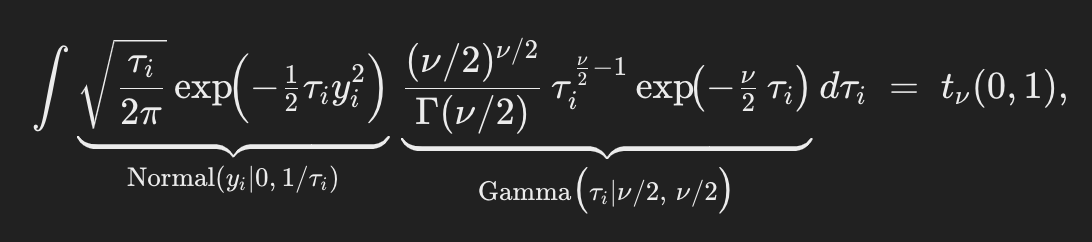

The behaviour demonstrated here is analagous to that of the posterior predictive distribution because the only difference in this example is that $\tau_i$ is being integrated out from its prior rather than its posterior. The exact the same principle as in posterior predictive inference is still used, the only difference is which distribution of $\tau_i$ we are using (the prior or posterior). We are still using the same priciple of forming a mixture over all possible values of $\tau_i$, weighted by the relevant distribution (prior or posterior).

#### Derivation of integrating out the uncertainty in $\tau_i$:

In [7]:
import sympy

tau, y, nu = sympy.symbols('tau y nu', positive=True, real=True)

alpha = nu / 2
beta  = nu / 2

# p(tau) = (beta^alpha / Gamma(alpha)) * tau^(alpha - 1) * exp(-beta * tau)
p_tau = (beta**alpha / sympy.gamma(alpha)) * tau**(alpha - 1) * sympy.exp(-beta * tau)

# define normal likelihood for y given tau:
# p(y | tau) = sqrt(tau/(2*pi)) * exp(-tau*y^2/2)
p_y_given_tau = sympy.sqrt(tau/(2*sympy.pi)) * sympy.exp(-tau*y**2/2)

# joint density is p(y, tau) = p(y|tau) * p(tau)
integrand = p_y_given_tau * p_tau

# integrate out tau to get p(y)
p_y = sympy.integrate(integrand, (tau, 0, sympy.oo))

p_y_simpl = sympy.simplify(p_y)

print(sympy.latex(p_y_simpl))

\frac{\nu^{\frac{\nu}{2}} \left(\nu + y^{2}\right)^{- \frac{\nu}{2} - \frac{1}{2}} \Gamma\left(\frac{\nu}{2} + \frac{1}{2}\right)}{\sqrt{\pi} \Gamma\left(\frac{\nu}{2}\right)}


The above solution is equal to:

$\frac{\nu^{\frac{\nu}{2}} \left(\nu + y^{2}\right)^{- \frac{\nu}{2} - \frac{1}{2}} \Gamma\left(\frac{\nu}{2} + \frac{1}{2}\right)}{\sqrt{\pi} \Gamma\left(\frac{\nu}{2}\right)}$,

which can be simplified to:

$\frac{\Gamma\!\Bigl(\frac{\nu+1}{2}\Bigr)}{\sqrt{\nu \pi}\,\Gamma\!\Bigl(\frac{\nu}{2}\Bigr)}
\;\left(1 + \frac{y^2}{\nu}\right)^{-\frac{\nu+1}{2}}$,

which is exactly the t-distribution with $\nu$ degrees of freedom, location=0, and scale=1.